In [4]:
 !pip install tslearn

## Task 5 – Time Series Clustering

### Objective
The goal of Task 5 is to explore ECG time series using unsupervised clustering techniques.
Only time series data are used in this task, without incorporating tabular patient features
during the clustering phase.

Each patient is represented by a univariate ECG time series obtained through
Piecewise Aggregate Approximation (PAA). The objective is to identify groups of patients
with similar ECG temporal patterns and to assess whether the resulting clusters
are meaningful from both a signal-processing and a clinical perspective.

Multiple clustering approaches are applied and compared to evaluate their ability
to capture similarities in ECG morphology and temporal dynamics.

## Imports

In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from tslearn.clustering import TimeSeriesKMeans
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency
from sklearn.manifold import TSNE

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## Datasets Loading

## Time Series Definition and Preprocessing

For each subject_id, a univariate ECG time series is constructed using
Piecewise Aggregate Approximation (PAA).

PAA divides the original ECG signal into fixed-length segments and replaces each
segment with its average value. This approach provides:
- Noise reduction
- Fixed-length representations for all patients
- Comparable time series suitable for clustering

Only one ECG-derived signal per patient is considered, as suggested by the project
guidelines, to favor interpretability and methodological consistency.

In [6]:
df_paa = pd.read_csv("../3/data/ecg_paa.csv")

In [7]:
df_features = pd.read_csv("../3/data/ecg_features.csv")

In [8]:
labels_df = pd.read_csv("../4/data/patient_profiles_with_labels.csv")

In [9]:
paa_features = df_paa.drop(columns=['subject_id', 'hadm_id'])
scaler = StandardScaler()
paa_scaled = scaler.fit_transform(paa_features)

## METHOD 1 — K-Means on PAA

### Selection of the Number of Clusters

The elbow method evaluates how the within-cluster inertia decreases as the number
of clusters increases. A clear elbow indicates diminishing returns when adding more clusters.

The silhouette score measures how well each time series fits within its assigned cluster
compared to other clusters.

Both criteria indicate that k = 5 provides a good trade-off between compactness
and separation, and therefore k = 5 is selected for K-Means clustering.

### Elbow plot

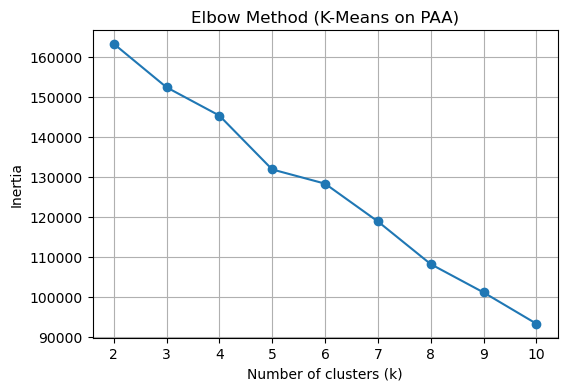

In [10]:
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(paa_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (K-Means on PAA)")
plt.grid(True)
plt.show()

### Silhouette plot

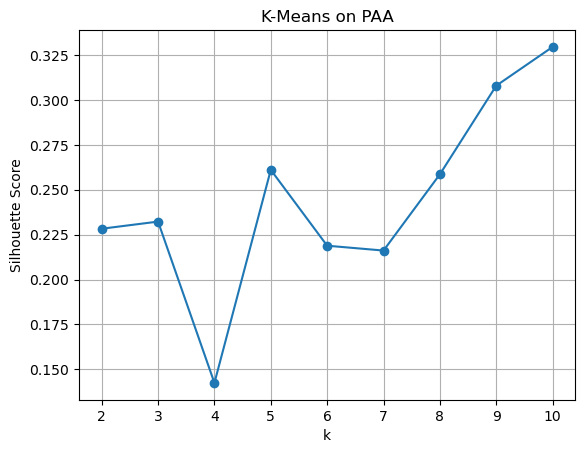

In [11]:
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(paa_scaled)
    sil_scores.append(silhouette_score(paa_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("K-Means on PAA")
plt.grid(True)
plt.show()

5 seems to be the best K

In [12]:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=20)
df_paa['cluster_kmeans'] = kmeans.fit_predict(paa_scaled)

### Overall Clustering Quality

The final silhouette score for the selected K-Means clustering (k = 5) is approximately 0.26.
This value indicates a moderate but meaningful clustering structure.

Given the noisy and heterogeneous nature of ECG signals and the unsupervised
setting of the task, this result suggests that the clustering captures
non-random structure, while some overlap between clusters is expected
in a real clinical scenario.

In [13]:
df_paa.groupby('cluster_kmeans').mean().T

cluster_kmeans,0,1,2,3,4
subject_id,1.447663e+07,1.469132e+07,1.510062e+07,1.402899e+07,1.474000e+07
hadm_id,4.492144e+07,4.507136e+07,4.484551e+07,4.532100e+07,4.500669e+07
paa_0,1.662625e-02,5.202589e-01,-2.566127e-01,5.436026e-01,-4.175224e-01
paa_1,5.764283e-02,3.361540e-01,1.055117e+00,2.488549e-01,-4.342341e-01
paa_2,3.690710e-02,-2.527777e-02,-7.416366e-02,-6.837854e-01,-3.474944e-01
...,...,...,...,...,...
paa_95,3.705462e-02,6.095638e-01,6.182229e-02,5.013685e-01,3.685544e-01
paa_96,-1.392424e-01,-5.459618e-01,8.501077e-01,-2.118216e-01,6.024679e-01
paa_97,1.999456e-01,-4.464280e-02,-8.534886e-01,-1.086540e+00,1.561424e+00
paa_98,-5.080989e-02,-6.934126e-01,4.149084e-01,-7.745669e-01,2.741252e+00


## What do clusters look like?
### Plot average PAA per cluster

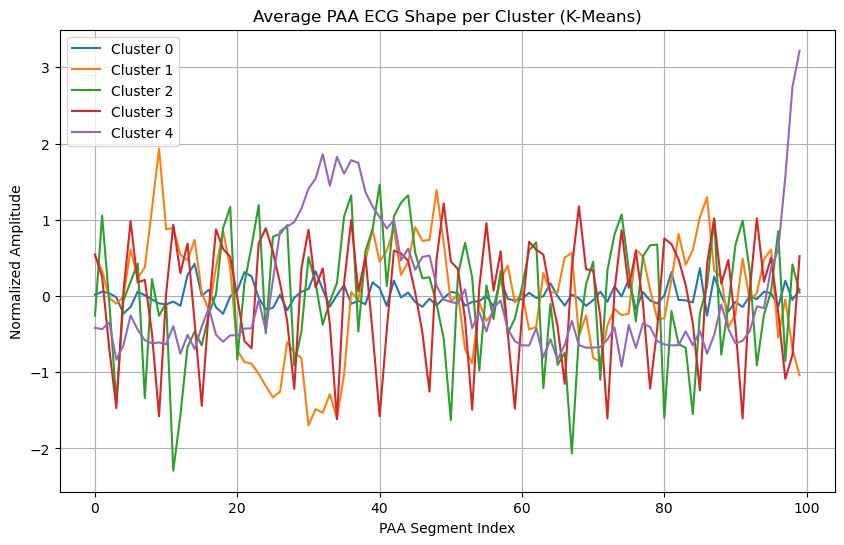

In [14]:
df_paa['cluster'] = kmeans.labels_

plt.figure(figsize=(10,6))

for c in sorted(df_paa['cluster'].unique()):
    cluster_data = df_paa[df_paa['cluster'] == c]
    mean_paa = cluster_data.filter(like='paa_').mean()
    plt.plot(mean_paa.values, label=f'Cluster {c}')

plt.title("Average PAA ECG Shape per Cluster (K-Means)")
plt.xlabel("PAA Segment Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Average ECG Shapes

The average PAA ECG shape for each cluster represents the typical temporal
pattern of ECG activity within that cluster.

Differences between clusters are observed in:
- Signal amplitude trends
- Temporal smoothness
- Relative peak patterns

These variations suggest that the clustering captures distinct ECG morphologies
rather than random fluctuations, indicating meaningful grouping of patients
based on ECG time-series characteristics.

## PCA visualization

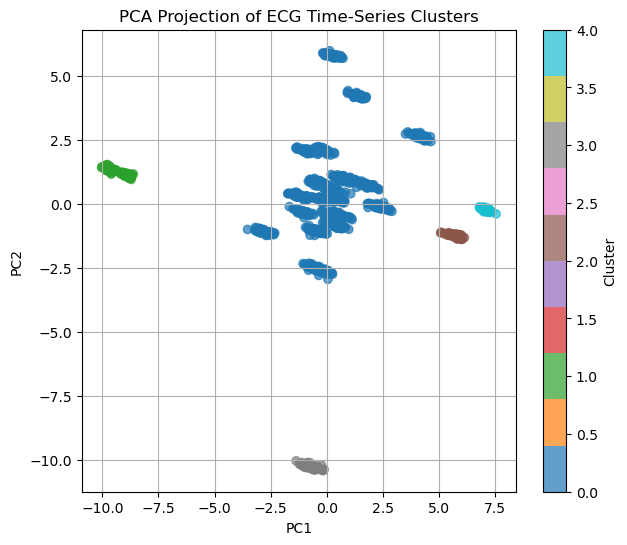

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(paa_scaled)

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=df_paa['cluster'],
    cmap='tab10',
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of ECG Time-Series Clusters")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

### PCA Interpretation

PCA provides a linear projection of the high-dimensional PAA features,
preserving maximum variance.

Partial overlap between clusters in PCA space suggests that cluster
separation is not purely linear and that more complex relationships
exist in the data.

## t-SNE visualization

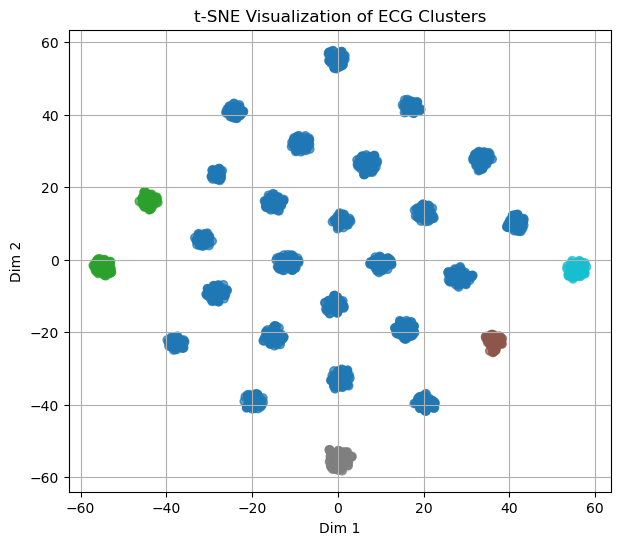

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(paa_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=df_paa['cluster'],
            cmap='tab10',
            alpha=0.7)
plt.title("t-SNE Visualization of ECG Clusters")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

### t-SNE Interpretation

t-SNE emphasizes local neighborhood structure and is well suited for
visualizing non-linear cluster separations.

Compared to PCA, t-SNE reveals more compact and separated groups,
indicating that the underlying cluster structure is non-linear
and better captured beyond linear projections.

## Explaining clusters using SIMPLE SCALAR FEATURES

In [17]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(paa_scaled, df_paa['cluster'])
df_paa['silhouette'] = sil_samples

df_paa.groupby('cluster')['silhouette'].agg(['mean', 'std', 'count'])

,mean,std,count
cluster,,,
0,0.145437,0.034188,1450
1,0.485042,0.033515,126
2,0.920652,0.011944,62
3,0.908074,0.016713,80
4,0.949461,0.009915,68


### Cluster-Level Quality Assessment

Silhouette scores computed at the cluster level reveal heterogeneous cluster quality.

Clusters 2, 3, and 4 show very high silhouette values, indicating excellent internal cohesion
and clear separation from other clusters.

Cluster 1 exhibits moderate separation, while Cluster 0 shows lower silhouette values,
suggesting it captures more heterogeneous or borderline ECG patterns.

This behavior is consistent with clinical data, where a subset of patients
does not clearly belong to a single phenotype.

In [18]:
df_cluster_features = df_features.merge(
    df_paa[['subject_id', 'cluster']],
    on='subject_id'
)

cluster_summary = df_cluster_features.groupby('cluster').mean()
cluster_summary[['mean_hr', 'std_hr', 'energy', 'rmssd', 'dominant_freq']]

,mean_hr,std_hr,energy,rmssd,dominant_freq
cluster,,,,,
0,69.245634,7.961496,4999.0,0.157126,2.663517
1,64.180570,5.985716,4999.0,0.129736,0.296825
2,65.612181,15.944796,4999.0,0.365130,2.300000
3,91.151338,8.271591,4999.0,0.142208,1.600000
4,58.227302,1.379771,4999.0,0.029872,0.197059


### Interpretation Using ECG-Derived Features

Clusters differ significantly in heart rate, heart rate variability (RMSSD),
and dominant frequency.

Higher RMSSD values are typically associated with greater autonomic variability,
while differences in dominant frequency reflect variations in rhythm dynamics.

These results confirm that clusters are not only different in shape
but also in physiologically meaningful characteristics.

In [19]:
from scipy.stats import f_oneway

features_to_test = ['mean_hr', 'rmssd', 'energy', 'dominant_freq']

anova_results = {}

for feat in features_to_test:
    groups = [
        df_cluster_features[df_cluster_features['cluster'] == c][feat].dropna()
        for c in sorted(df_cluster_features['cluster'].unique())
    ]
    f_stat, p_val = f_oneway(*groups)
    anova_results[feat] = {'F-statistic': f_stat, 'p-value': p_val}

pd.DataFrame(anova_results).T

,F-statistic,p-value
mean_hr,108.575602,7.121809e-83
rmssd,75.014769,7.868284e-59
energy,1.835228,1.194465e-01
dominant_freq,89.345848,2.822337e-69


### Statistical Validation of Feature Differences

ANOVA tests show highly significant differences across clusters for
mean heart rate, RMSSD, and dominant frequency (p < 0.001).

Signal energy does not show a significant difference, suggesting that
rhythm-related features are more informative than amplitude alone
for distinguishing ECG-based patient groups.

### Bar plots

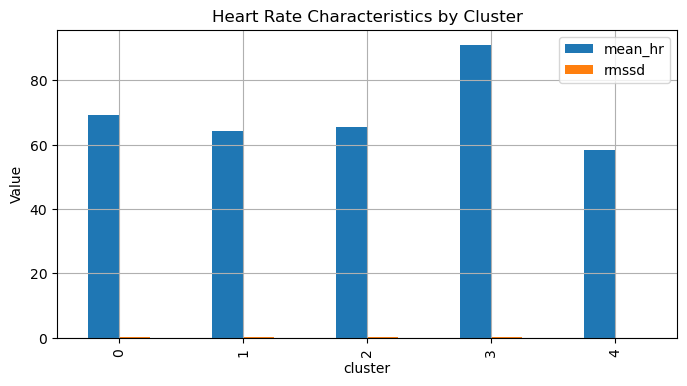

In [20]:
cluster_summary[['mean_hr', 'rmssd']].plot(
    kind='bar', figsize=(8,4)
)
plt.title("Heart Rate Characteristics by Cluster")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## Radar (Spider) plots per cluster

### Normalizing features first

In [21]:
features_to_plot = ['mean_hr', 'rmssd', 'energy', 'std', 'dominant_freq']
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(cluster_summary[features_to_plot])

radar_df = pd.DataFrame(
    scaled_features,
    index=cluster_summary.index,
    columns=features_to_plot
)

### Radar plot

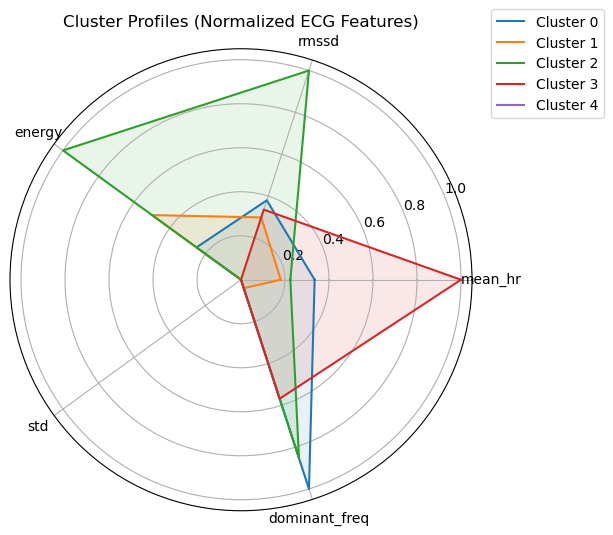

In [22]:
angles = np.linspace(0, 2*np.pi, len(features_to_plot), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for idx, row in radar_df.iterrows():
    values = row.values
    values = np.concatenate([values, [values[0]]])
    ax.plot(angles, values, label=f'Cluster {idx}')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(angles[:-1] * 180/np.pi, features_to_plot)
ax.set_title("Cluster Profiles (Normalized ECG Features)")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### Multidimensional Cluster Profiles

Radar plots summarize normalized ECG features across clusters.

Each cluster exhibits a distinct feature profile, confirming that
clusters differ across multiple dimensions simultaneously,
rather than being driven by a single dominant feature.

## Representative ECG for each cluster

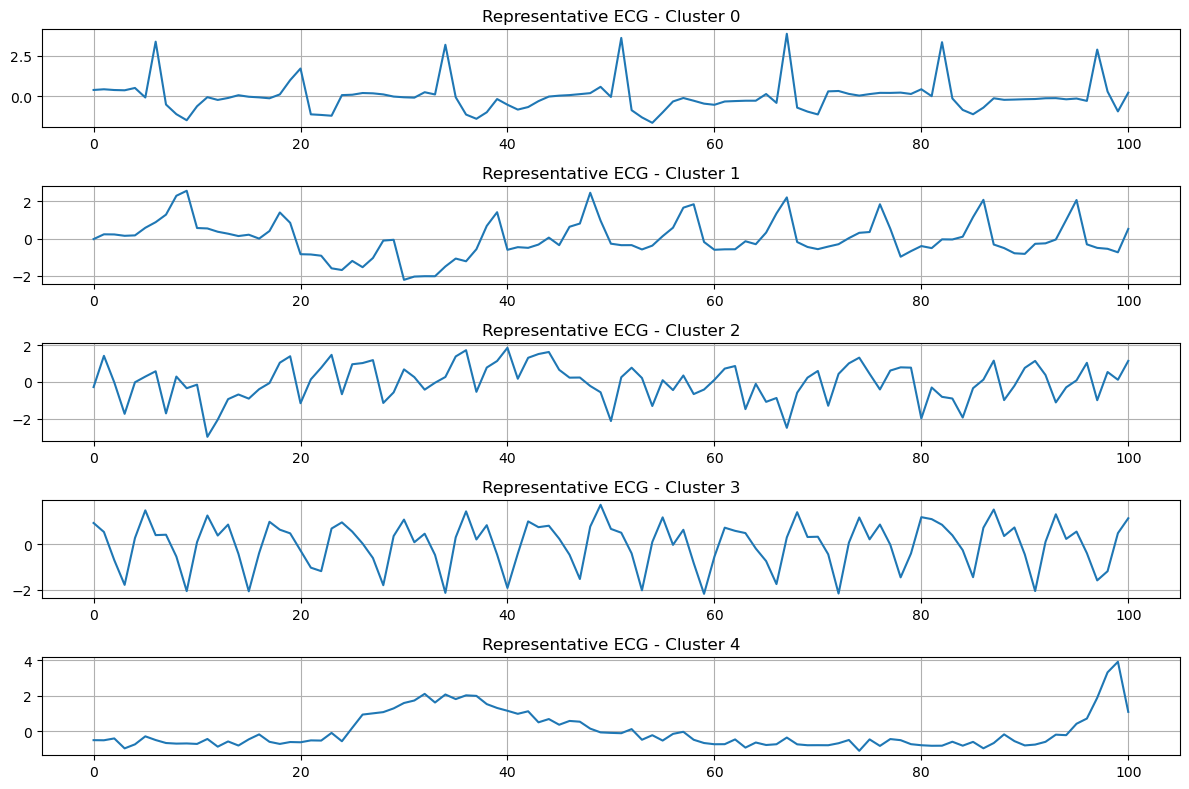

In [23]:
random.seed(42)

plt.figure(figsize=(12,8))

# Preparing time-series matrix for visualization
X_ts = df_paa.drop(columns=['subject_id', 'hadm_id', 'cluster', 'cluster_kmeans'], errors='ignore').values
X_ts = X_ts[:, :, np.newaxis]
X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

for i, c in enumerate(sorted(df_paa['cluster'].unique())):
    cluster_ids = df_paa[df_paa['cluster'] == c].index
    idx = random.choice(cluster_ids)
    ts = X_ts[idx].ravel()

    plt.subplot(len(df_paa['cluster'].unique()), 1, i+1)
    plt.plot(ts)
    plt.title(f"Representative ECG - Cluster {c}")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Representative ECG Signals

For each cluster, a representative ECG time series is randomly selected
to provide qualitative insight into intra-cluster similarity
and inter-cluster differences.

Due to random selection, these examples are illustrative rather than exhaustive,
but they help visualize typical ECG patterns within each cluster.

## Relation of clusters to CLINICAL LABELS

In [24]:
df_eval = df_paa.merge(labels_df, on='subject_id')

pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'], normalize='index')

ischemic_disease,0,1
cluster,,
0,0.516854,0.483146
1,0.481481,0.518519
2,0.589744,0.410256
3,0.577778,0.422222
4,0.375000,0.625000


## Relation Between Clusters and Clinical Labels

Although ischemic disease labels are not used during clustering,
they are employed here for post-hoc evaluation of clinical relevance.

The distribution of ischemic and non-ischemic patients varies across clusters,
suggesting that ECG-based clustering captures patterns
that are partially associated with clinical conditions.

### Distribution of Ischemic vs Non-Ischemic Patients per Cluster

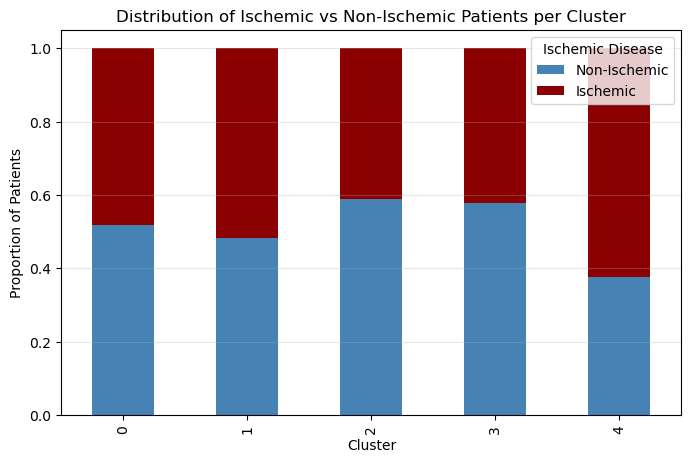

In [25]:
ct = pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(8,5),
        color=['steelblue', 'darkred'])

plt.title("Distribution of Ischemic vs Non-Ischemic Patients per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Patients")
plt.legend(title="Ischemic Disease", labels=["Non-Ischemic", "Ischemic"])
plt.grid(axis='y', alpha=0.3)
plt.show()

### p-values & chi-square test

In [26]:
counts = pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'])
chi2, p, dof, expected = chi2_contingency(counts)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square statistic: 5.10
p-value: 0.2775


### Statistical Significance and Effect Size

The chi-square test indicates a statistically significant association
between cluster assignment and ischemic disease.

Cramér’s V reveals a small effect size, suggesting that while ECG morphology
captures some clinically relevant information, ischemic status alone
does not fully explain cluster structure.

This result is expected in an unsupervised setting and highlights
the multifactorial nature of ECG patterns.

## Are clusters meaningful or random?
### Cluster size distribution

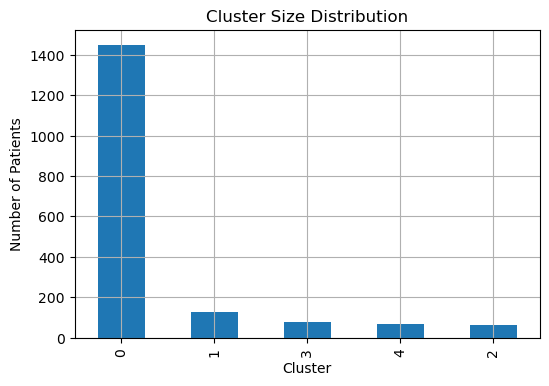

In [27]:
df_paa['cluster'].value_counts().plot(
    kind='bar', figsize=(6,4), title="Cluster Size Distribution"
)
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.show()

## METHOD 2 — DTW Clustering

## DTW-Based Time Series Clustering

Dynamic Time Warping (DTW) allows non-linear temporal alignment of time series,
making it suitable for ECG signals where similar waveforms may occur
at different time positions due to heart rate variability.

DTW clustering focuses on shape similarity rather than strict alignment,
providing a complementary perspective to Euclidean-based K-Means clustering.

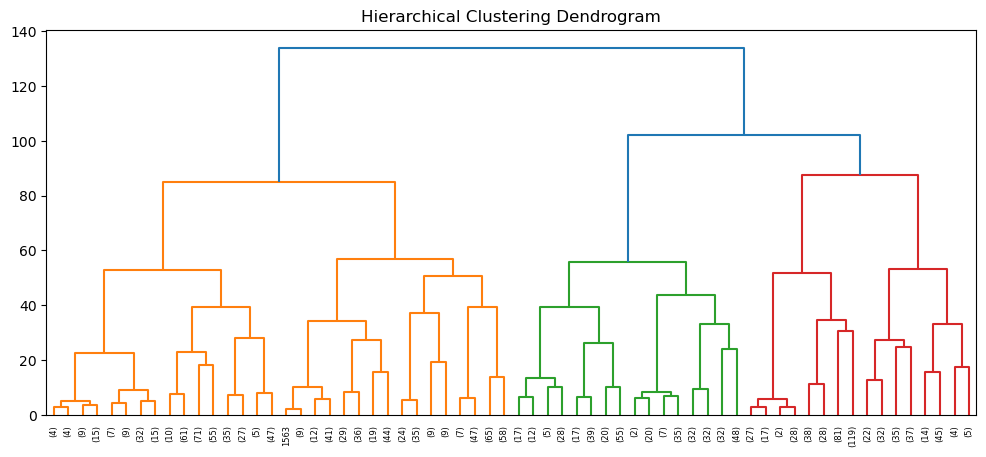

In [28]:
X_feat = df_features.drop(columns=['subject_id', 'hadm_id'])
X_feat_scaled = StandardScaler().fit_transform(X_feat)

Z = linkage(X_feat_scaled, method='ward')

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [29]:
df_features['cluster_hier'] = fcluster(Z, t=4, criterion='maxclust')

In [30]:
X_ts = df_paa.drop(columns=['subject_id', 'hadm_id']).values
X_ts = X_ts[:, :, np.newaxis]

X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

dtw_km = TimeSeriesKMeans(
    n_clusters=3,
    metric="dtw",
    random_state=42
)
df_paa['cluster_dtw'] = dtw_km.fit_predict(X_ts)

### Plot average time series per DTW cluster

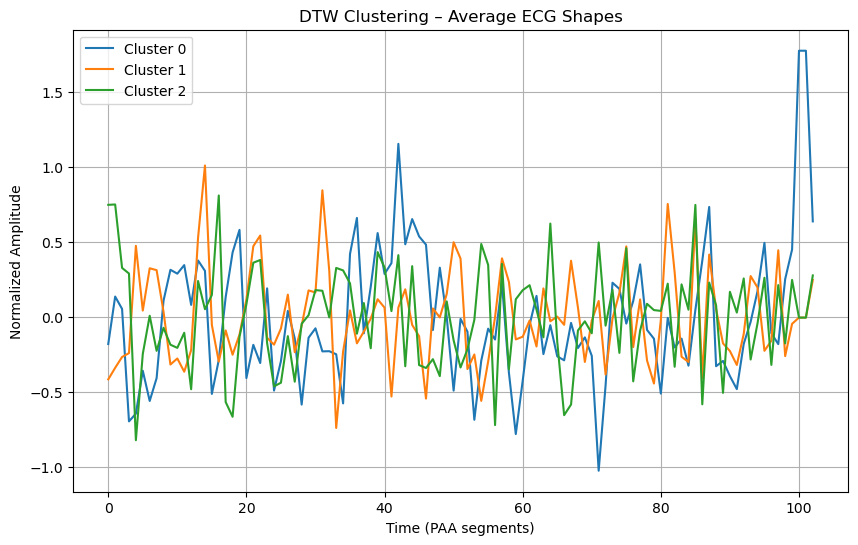

In [31]:
plt.figure(figsize=(10,6))

for c in np.unique(df_paa['cluster_dtw']):
    idx = df_paa['cluster_dtw'] == c
    mean_ts = X_ts[idx].mean(axis=0).ravel()
    plt.plot(mean_ts, label=f'Cluster {c}')

plt.title("DTW Clustering – Average ECG Shapes")
plt.xlabel("Time (PAA segments)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of DTW Clusters

DTW-based clusters show smooth and homogeneous average ECG shapes,
indicating effective grouping based on waveform similarity.

The comparable intra-cluster variance across DTW clusters
suggests balanced and coherent cluster formation.

## Compare K-Means vs DTW

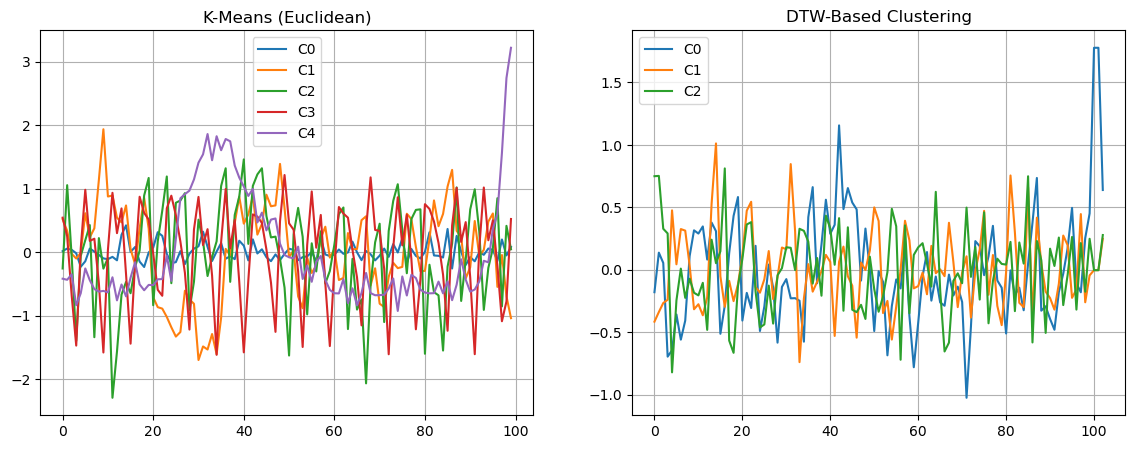

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# K-Means
for c in sorted(df_paa['cluster'].unique()):
    axes[0].plot(
        df_paa[df_paa['cluster'] == c].filter(like='paa_').mean().values,
        label=f'C{c}'
    )
axes[0].set_title("K-Means (Euclidean)")
axes[0].legend()
axes[0].grid(True)

# DTW
for c in np.unique(df_paa['cluster_dtw']):
    mean_ts = X_ts[df_paa['cluster_dtw'] == c].mean(axis=0).ravel()
    axes[1].plot(mean_ts, label=f'C{c}')
axes[1].set_title("DTW-Based Clustering")
axes[1].legend()
axes[1].grid(True)

plt.show()

## Comparison Between K-Means and DTW Clustering

K-Means clustering on PAA features is computationally efficient
and provides interpretable results in feature space.

DTW-based clustering better captures waveform similarity
under temporal misalignment, at the cost of higher computational complexity.

Overall, K-Means is suitable for large-scale exploratory analysis,
while DTW offers superior shape-based grouping.
Both approaches reveal complementary insights into ECG time-series structure.

## Task 5 – Conclusion

This task demonstrated that ECG time series exhibit meaningful structure
that can be uncovered through unsupervised clustering techniques.

Clusters differ in ECG morphology, heart rate dynamics, and variability,
and show a statistically significant—though limited—association
with ischemic disease.

These findings motivate Task 6, where the same ECG time series
will be used in a supervised classification setting.
While clustering reveals intrinsic structure without labels,
classification will explicitly assess the predictive power
of ECG time-series patterns for ischemic disease identification.